In [8]:
import pickle

import numpy as np
import matplotlib.pyplot as plt
import json
import sqlite3

In [9]:
file = "results/tag_results_len13.pkl"

def stream_results(filename):
    with open(filename, 'rb') as f:
        while True:
            try:
                # Reads the next object from the stream
                yield pickle.load(f)
            except EOFError:
                # We reached the end of the file
                break

In [33]:
import bisect

max_runtime = 100_001
num_runtimes = np.zeros(max_runtime, dtype=int)
num_runtimes_weighted = np.zeros(max_runtime, dtype=float)

# Precompute cumulative counts and weights for O(1) lookup
lengths = list(range(3, 25))
partitions = [(l - 1) * (l - 2) // 2 for l in lengths]
counts = [(3 ** (l + 1)) * p for l, p in zip(lengths, partitions)]
cum_counts = list(np.cumsum(counts))

# Weighting by total rule length (4-character alphabet: 'a','b','c','H')
weights_lookup = [4 ** (-(l + 1)) for l in lengths]
# (If weighting by 3-character base string length, use: [3 ** (-l) for l in lengths])

counter = 0
for result in stream_results(file):
    counter += 1
    program_index, steps = result
    
    # Reconstruct length and weight
    len_idx = bisect.bisect_right(cum_counts, program_index)
    weight = weights_lookup[len_idx]
    
    num_runtimes[steps] += 1
    num_runtimes_weighted[steps] += weight

    if counter % 1_000_000 == 0:
        print(f"Processed {counter:,} results, most common runtime: {np.argmax(num_runtimes[:1000])} with {max(num_runtimes[:1000])} programs")


Processed 1,000,000 results, most common runtime: 2 with 311426 programs
Processed 2,000,000 results, most common runtime: 2 with 595906 programs
Processed 3,000,000 results, most common runtime: 2 with 861364 programs
Processed 4,000,000 results, most common runtime: 2 with 1106540 programs
Processed 5,000,000 results, most common runtime: 2 with 1358471 programs
Processed 6,000,000 results, most common runtime: 2 with 1603372 programs
Processed 7,000,000 results, most common runtime: 2 with 1847054 programs
Processed 8,000,000 results, most common runtime: 2 with 2106833 programs
Processed 9,000,000 results, most common runtime: 2 with 2364012 programs
Processed 10,000,000 results, most common runtime: 2 with 2601841 programs
Processed 11,000,000 results, most common runtime: 2 with 2815655 programs
Processed 12,000,000 results, most common runtime: 2 with 3026252 programs
Processed 13,000,000 results, most common runtime: 2 with 3237938 programs
Processed 14,000,000 results, most co

In [34]:
print(result)

(435839999, 7)


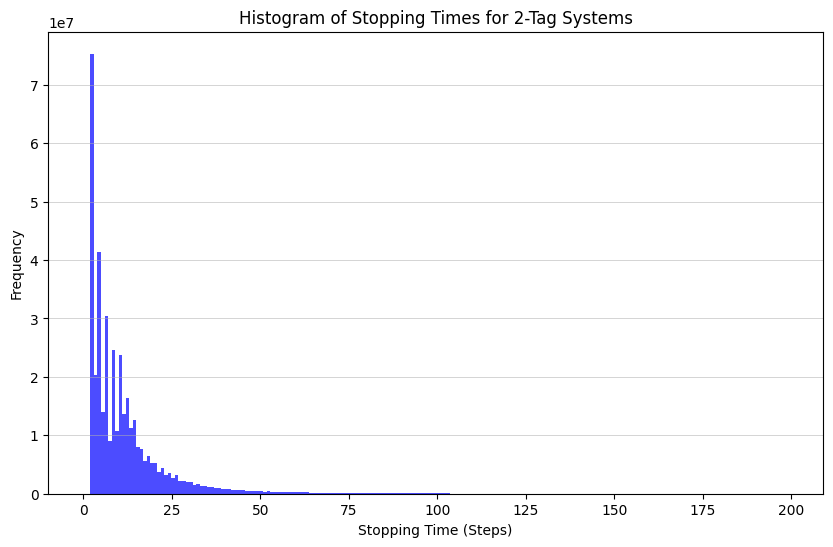

In [37]:
# coarse-grained histogram
num_bins = 200
max_plotted_runtime = 200
halting_num_runtimes = num_runtimes[:max_plotted_runtime]
hist, bin_edges = np.histogram(np.arange(max_plotted_runtime), bins=num_bins, weights=halting_num_runtimes)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.bar(bin_centers, hist, width=bin_edges[1] - bin_edges[0], alpha=0.7, color='blue')
plt.title('Histogram of Stopping Times for 2-Tag Systems')
plt.xlabel('Stopping Time (Steps)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [38]:
print(f"Percentage of programs that halt: {np.sum(num_runtimes[:-1]) * 100 / np.sum(num_runtimes)}%")

Percentage of programs that halt: 100.0%


In [39]:
# list runtimes from most common to least common
sorted_indices = np.argsort(num_runtimes)[::-1]  # Sort in descending order
sorted_runtimes = num_runtimes[sorted_indices]

In [40]:
# print 100 most common runtimes
print("Most common runtimes (steps):")
for i in range(100):
    runtime = sorted_indices[i]
    frequency = sorted_runtimes[i]
    print(f"Runtime: {runtime}, Frequency: {frequency}")

Most common runtimes (steps):
Runtime: 2, Frequency: 75331782
Runtime: 4, Frequency: 41452911
Runtime: 6, Frequency: 30392808
Runtime: 8, Frequency: 24630721
Runtime: 10, Frequency: 23828970
Runtime: 3, Frequency: 20327679
Runtime: 12, Frequency: 16470083
Runtime: 5, Frequency: 13954923
Runtime: 11, Frequency: 13690888
Runtime: 14, Frequency: 12544730
Runtime: 13, Frequency: 11293742
Runtime: 9, Frequency: 10817194
Runtime: 7, Frequency: 9012907
Runtime: 15, Frequency: 8081360
Runtime: 16, Frequency: 7645006
Runtime: 18, Frequency: 6516436
Runtime: 17, Frequency: 5666612
Runtime: 20, Frequency: 5336908
Runtime: 19, Frequency: 5246444
Runtime: 22, Frequency: 4457818
Runtime: 21, Frequency: 3668364
Runtime: 24, Frequency: 3589570
Runtime: 23, Frequency: 3225104
Runtime: 26, Frequency: 3176720
Runtime: 25, Frequency: 2699662
Runtime: 27, Frequency: 2137002
Runtime: 28, Frequency: 2109244
Runtime: 29, Frequency: 1931792
Runtime: 30, Frequency: 1930774
Runtime: 32, Frequency: 1654686
Runtim

In [41]:
# print all runtimes that occur exactly once or twice
print("Runtimes that occur exactly once or twice:")
num_runtimes_at_most_twice = 0
for i in range(max_runtime):
    if num_runtimes[i] <= 2 and num_runtimes[i] > 0:
        print(f"Runtime: {i}, Frequency: {num_runtimes[i]}")
        num_runtimes_at_most_twice += 1

print(f"Total number of runtimes that occur at most twice: {num_runtimes_at_most_twice}")

Runtimes that occur exactly once or twice:
Runtime: 758, Frequency: 2
Runtime: 786, Frequency: 2
Runtime: 852, Frequency: 2
Runtime: 872, Frequency: 2
Runtime: 902, Frequency: 2
Runtime: 913, Frequency: 2
Runtime: 919, Frequency: 2
Runtime: 936, Frequency: 2
Runtime: 958, Frequency: 2
Runtime: 1000, Frequency: 2
Runtime: 1017, Frequency: 2
Runtime: 1019, Frequency: 2
Runtime: 1021, Frequency: 2
Runtime: 1036, Frequency: 2
Runtime: 1038, Frequency: 2
Runtime: 1053, Frequency: 2
Runtime: 1064, Frequency: 2
Runtime: 1080, Frequency: 2
Runtime: 1082, Frequency: 2
Runtime: 1104, Frequency: 2
Runtime: 1107, Frequency: 2
Runtime: 1108, Frequency: 2
Runtime: 1115, Frequency: 2
Runtime: 1135, Frequency: 2
Runtime: 1137, Frequency: 2
Runtime: 1149, Frequency: 2
Runtime: 1154, Frequency: 2
Runtime: 1187, Frequency: 2
Runtime: 1203, Frequency: 2
Runtime: 1205, Frequency: 2
Runtime: 1213, Frequency: 2
Runtime: 1224, Frequency: 2
Runtime: 1229, Frequency: 2
Runtime: 1233, Frequency: 2
Runtime: 1234,

In [42]:
# write runtimes ordered by frequency to a csv file
import csv
with open('results/tag_runtimes_frequency_len13.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Runtime (Steps)', 'Frequency'])
    for i in range(len(sorted_indices)):
        runtime = sorted_indices[i]
        frequency = sorted_runtimes[i]
        if frequency == 0:
            break
        writer.writerow([runtime, frequency])

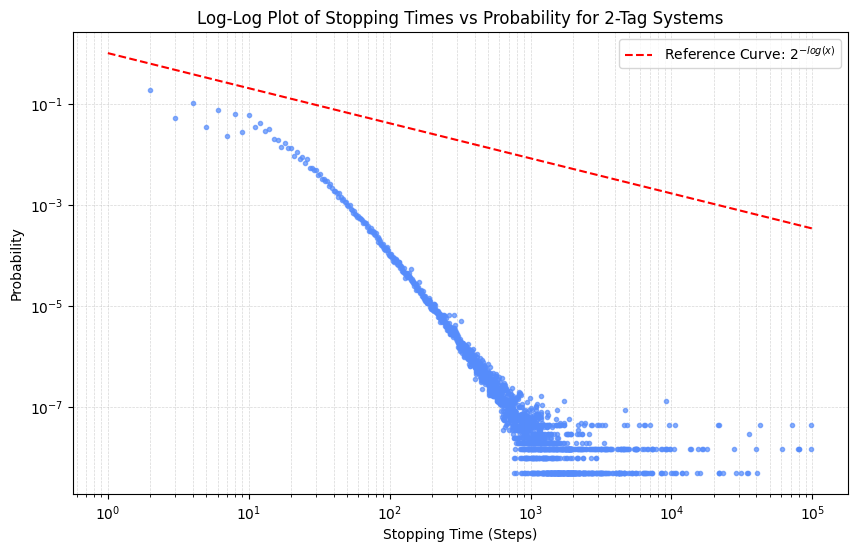

In [44]:
# log-log plot of runtimes against probability
total_programs = np.sum(num_runtimes)
probabilities = num_runtimes / total_programs

# Create a log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(np.arange(max_runtime), probabilities, marker='o', linestyle='None', markersize=3, alpha=0.7)

reference_curve = 2 ** (-np.log(np.arange(1, max_runtime)))
plt.loglog(np.arange(1, max_runtime), reference_curve, color='red', linestyle='--', label='Reference Curve: $2^{-log(x)}$')
plt.legend()

plt.title('Log-Log Plot of Stopping Times vs Probability for 2-Tag Systems')
plt.xlabel('Stopping Time (Steps)')
plt.ylabel('Probability')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

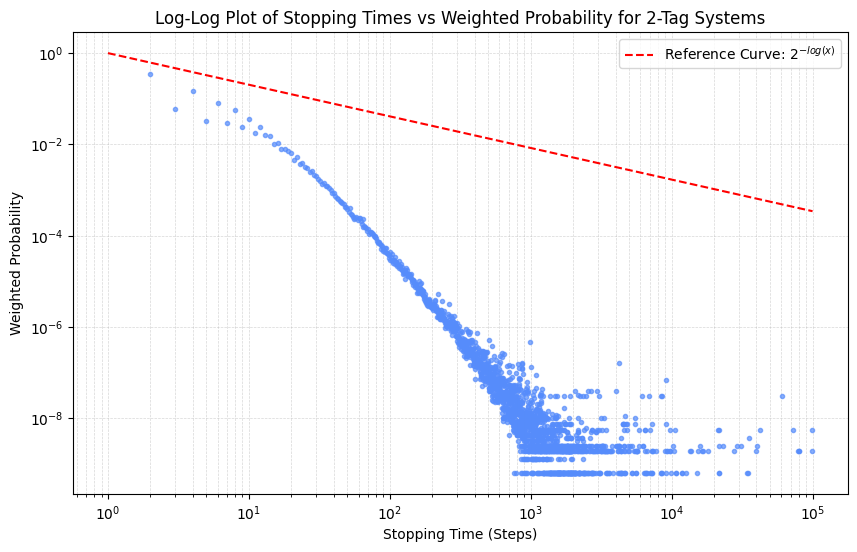

In [51]:
# same plot, but weighted by program length
total_weighted_programs = np.sum(num_runtimes_weighted)
weighted_probabilities = num_runtimes_weighted / total_weighted_programs

# Create a log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(np.arange(max_runtime), weighted_probabilities, marker='o', linestyle='None', markersize=3, alpha=0.7)

# add a curve 2**(- log x) as reference
reference_curve = 2 ** (-np.log(np.arange(1, max_runtime)))
plt.loglog(np.arange(1, max_runtime), reference_curve, color='red', linestyle='--', label='Reference Curve: $2^{-log(x)}$')
plt.legend()

plt.title('Log-Log Plot of Stopping Times vs Weighted Probability for 2-Tag Systems')
plt.xlabel('Stopping Time (Steps)')
plt.ylabel('Weighted Probability')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

In [ ]:
1